# Proyecto INE

## Indice

1. [Introduccion](#introduccion)
2. [Marco Teorico](#marco-teorico)
3. [Analisis Temporal Desocupación](#analisis-temporal-desocupación)
4. [Analisis Temporal Ocupación]
5. [Analisis por Tramo de Edad]
6. [Conclusiones]
7. [Anexo](#anexo)

## Introduccion 

In [2]:
# Modules to use
import pandas as pd
import seaborn as sns
import numpy as np
import scipy
import matplotlib.pyplot as plt
import warnings
from statsmodels.stats import proportion, multitest

warnings.filterwarnings("ignore", category=FutureWarning)
# Load database
data = pd.read_csv("ano-2025.csv", sep=";")
data.head()

C:\Users\crist\AppData\Local\Temp\ipykernel_21912\3132281422.py:12: DtypeWarning: Columns (28,43,69,77,81,119,150,155,162,164) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("ano-2025.csv", sep=";")


,ano_trimestre,mes_central,ano_encuesta,mes_encuesta,region,provincia,tipo,r_p_c,estrato,conglomerado,...,efectivas,tpi,ocup_form,sector,r_p_rev4cl_caenes,ftp,obe,id,asocia,fact_anual
0,2025,2,2025,1,15,151,1,15101,15000012,16230,...,44.0,0.0,2.0,1.0,15.0,NaN,0.0,NaN,0.0,"16,9307528055373"
1,2025,2,2025,1,15,151,1,15101,15000012,16230,...,44.0,0.0,1.0,1.0,9.0,NaN,0.0,NaN,0.0,"19,8570154818132"
2,2025,2,2025,1,15,151,1,15101,15000012,16230,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,"17,2612656164794"
3,2025,2,2025,1,15,151,1,15101,15000012,16230,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,"15,4560029879504"
4,2025,2,2025,1,15,151,1,15101,15000012,16230,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,"14,0544783242967"


Una vez cargada la base de datos, observamos el tamaño de esta y los valores que puede tener la variable "activ", que describe la situacion laboral de cada una de las personas encuestadas

In [3]:
print(data.shape)
data["activ"].value_counts().keys()

(390903, 185)


Index([1.0, 3.0, 2.0], dtype='float64', name='activ')

## Marco Teorico
Podemos notar que la variable sobre la situacion laboral de cada uno de los encuestados tiene 3 opciones, las cuales segun el INE son:

- 1: Ocupado
- 2: Desocupado
- 3: Fuera de la fuerza del trabajo

En base a estas opciones, el INE calcula la tasa de desocupacion y de ocupacion a partir de los datos obtenidos, utilizando las siguientes formulas

$$TD = \frac{DO}{FT} * 100$$
Donde,

$DO = $ Personas desocupadas

$FT = $ Fuerza del trabajo

$$TO = \frac{O}{PET} * 100$$

Donde, 

$O = $ Personas ocupadas

$PET = $ Personas en edad de trabajar (15 años en adelante)

Por lo tanto, como solo se considera la fuerza del trabajo para la desocupacion, en este grupo solo se consideran las primeras dos respuestas. De este modo, se pueden definir las variables $X_1,..., X_n$ que valen 1 si la i-esima persona esta desocupada o 0 si esta ocupada. Ademas, es posible notar que las variables no dependen entre si, por lo que podemos concluir que

$$X_1,..., X_n \overset{iid}{\sim} Bernoulli(p_D)$$

Ahora, podemos utilizar el estimador de maxima verosimilitud (EMV) de la distribucion de Bernoulli, el cual esta dado por

$$\hat{p}_D = \sum_{i = 1}^n \frac{X_i}{n} = \bar{X}$$

Es decir, el promedio muestral de las personas desocupadas que se encuentran dentro de la fuerza del trabajo, lo que coincide con la formula de la tasa de desocupacion, por lo que se puede calcular el EMV facilmente con este resultado. A partir de esto es que se calcularan intervalos de confianza y se realizaran las pruebas de hipotesis.

De la misma forma, para la tasa de ocupacion ahora estan las tres opciones, por lo que podemos definir las variables $Y_1,..., Y_n$ identicamente distribuidas con la siguiente funcion de densidad.

$$f(y) = p_1^{\frac{(y-2)(y-3)}{(1-2)(1-3)}} p_2^{\frac{(y-1)(y-3)}{(2-1)(2-3)}} p_3^{\frac{(y-1)(y-2)}{(3-1)(3-2)}}, \ \ \ y = 1, 2, 3, \ \ \ p_1 + p_2 + p_3 = 1$$

donde $p_1$, $p_2$ y $p_3$ son las probabilidades de que una persona se encuentre ocupada, desocupada o fuera de la fuerza del trabajo respectivamente. En base a esta funcion de densidad, podemos calcular el EMV para $p_1$ y se puede demostrar que este tiene la formula que utiliza el INE para la tasa de desocupacion, por lo que podemos utilizar su distribucion asintotica (desarrollo en el [anexo](#anexo)), de modo que

$$\hat{p}_1 = \frac{TO}{PET}$$
$$\hat{p}_1 \overset{a}{\sim} N(p_1, \frac{p_1}{n})$$



## Analisis Temporal Desocupación
En esta seccion queremos responder las siguiente pregunta

> ¿Han cambiado la tasas de desocupacion en Chile durante el año 2025?

Para esto, se analizara el cambio de estas tasas a lo largo de los meses del año y se realizarán análisis estadísticos para recopilar evidencia para responder estas preguntas. En primer lugar, analicemos la tasa de desocupación

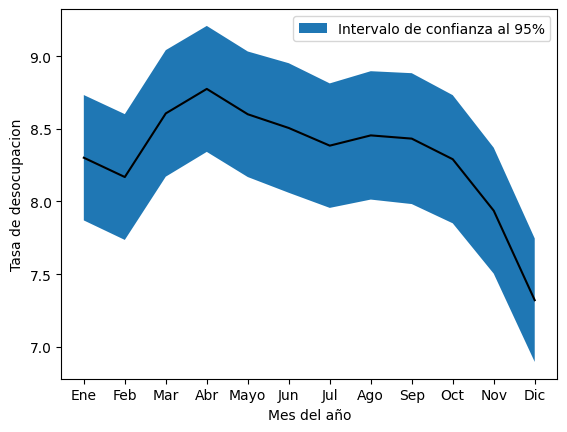

Tamaños muestrales según mes de la encuesta
mes_encuesta
Ene     15721
Feb     15389
Mar     15954
Abr     16377
Mayo    16186
Jun     15049
Jul     16090
Ago     15246
Sep     14634
Oct     15029
Nov     14956
Dic     14452
Name: activ, dtype: int64


In [14]:
def icbernoulli(df: pd.DataFrame):
    alpha = 0.05
    cuantil = scipy.stats.norm.ppf(1-alpha/2)
    td = len(df[df["activ"] == 2]) / len(df)
    error = cuantil * np.sqrt(td * (1 - td) / len(df))
    return [(td - error) * 100, (td + error) * 100]

fuerza_trabajo = data[(data["activ"] != 3) & (data["activ"].notnull())]
meses = ["Ene", "Feb", "Mar", "Abr", 
         "Mayo", "Jun", "Jul", "Ago",
         "Sep", "Oct", "Nov", "Dic"]
data_mensual = fuerza_trabajo.groupby("mes_encuesta")

tamanos_muestrales = data_mensual["activ"].count()
tamanos_muestrales = tamanos_muestrales.rename(index={i: meses[i - 1] for i in range(1, 13)})

tasas_desocupacion = data_mensual.apply(lambda df: len(df[df["activ"] == 2]) / len(df) * 100)
ics_95 = data_mensual.apply(icbernoulli)
ic_inf = []
ic_sup = []
for ic_95 in ics_95:
    ic_inf.append(ic_95[0])
    ic_sup.append(ic_95[1])
plt.plot(meses, tasas_desocupacion.values, color="black")
plt.xlabel("Mes del año")
plt.ylabel("Tasa de desocupacion")

plt.fill_between(meses, ic_inf, ic_sup, label = "Intervalo de confianza al 95%")
plt.legend()
plt.show()
print("Tamaños muestrales según mes de la encuesta")
print(tamanos_muestrales)

En primer lugar, se puede observar que los tamaños muestrales para cada mes son lo suficienmente grandes como para considerar normalidad asintótica, por lo que podemos realizar la inferencia utilizando este supuesto.

En segundo lugar, a partir del grafico y los intervalos de confianza calculados es posible observar tanto subidas como bajadas de la tasa de desocupacion y que existen momentos del año en los que el intervalo de confianza es mas amplio, lo que indicaria una mayor incertidumbre respecto al valor real de este porcentaje. Ademas, a partir del mes de agosto es notable una constante disminucion de este valor, pero esta informacion no es suficiente como para sacar conclusiones, por lo que debemos realizar un test de hipotesis para comprobar si realmente estas variaciones observadas son estadisticamente significativas o no.
Por lo tanto, debemos realizar un analisis de contingencia utilizando la prueba chi cuadrado, para evaluar las siguientes hipotesis

$$H_0: \ \text{La ocupacion y desocupacion no dependen del mes del año} \ \ vs. \ \ H_1: \text{La ocupacion y desocupacion dependen del mes del año} $$

Como nos estamos centrando solo en la tasa de desocupacion, podemos remplantear las hipotesis como:

$$H_0: \ \text{La tasa desocupacion es igual en todo el año} \ \ vs. \ \ H_1: \text{La tasa de desocupacion varia en al menos un mes del año} $$

Por lo que ocupamos el test chi cuadrado para comparar los datos obtenidos con los datos esperados asumiendo la misma tasa de desocupacion todos los meses, es decir

$$n_\text{ocupados mes} = \frac{n_{ocupados} n_\text{total mes}}{n_{total}}$$

Ademas, para analizar la magnitud de esta dependencia, calculamos el tamaño de efecto V de Cramer

In [5]:
tabla_contingencia = data_mensual["activ"].value_counts().unstack()
prueba_chi2 = scipy.stats.chi2_contingency(tabla_contingencia)

x2 = prueba_chi2.statistic
p_value = prueba_chi2.pvalue
dof = prueba_chi2.dof
v_cramer = np.sqrt(x2 / (len(fuerza_trabajo) * min(np.array(tabla_contingencia.shape) - 1)))

print("Valor-p de la prueba chi cuadrado:", p_value)
print("Valor del estadistico de la prueba:", x2)
print("Grados de libertad de la prueba:", dof)
print("V de Cramer obtenido:", v_cramer)

Valor-p de la prueba chi cuadrado: 0.0009343274603602447
Valor del estadistico de la prueba: 31.449213776905378
Grados de libertad de la prueba: 11
V de Cramer obtenido: 0.013035318023899881


Como se obtuvo un valor-p de 0,0009, esto implica que si la tasa de desocupacion fuera igual todo el año, obtener un estadistico de la prueba mayor o igual a 31,449 seria muy baja. Ademas, se obtuvo un tamaño de efecto muy pequeño de aproximadamente 0,013, lo que podria implicar que las variaciones apreciadas en el grafico anterior son pequeñas y dificiles de notar. Por lo tanto, considerando una significancia del 5%, existe evidencia estadística significativa para concluir que la tasa de desocupacion no es la misma todos los meses y va variando durante el año, pero que en la práctica no existen desviaciones altas de la tasa, por lo que habría que hacer un ánalisis comparativo entre cada uno de los meses para observar las diferencias. Sin embargo, estos resultados solo son representativos para la situación laboral nacional durante el año 2025, por lo que no son válidas en cualquier periodo de tiempo ni se pueden utilizar para predecir los cambios que pueden venir en el futuro.

Ahora, como se menciono anteriormente, queremos comprobar en que momentos del año difiere este porcentaje, por lo que realizamos pruebas post-hoc de comparaciones de proporciones utilizando la corrección de Holm Bonferroni para corregir los valores-p y minimizar la probabilidad de errores que se podrían cometer

In [6]:
total = data_mensual["activ"].count()
ocupados = tabla_contingencia[2.0]

pruebas = []

comparaciones = {i: [i] for i in range(1, 13)}
for mes_1 in range(1, 13):
    for mes_2 in range(1, 13):
        if mes_2 not in comparaciones[mes_1] or mes_1 not in comparaciones[mes_2]:
            zstat, pvalue = proportion.proportions_ztest(count=[ocupados[mes_1], ocupados[mes_2]],
                              nobs=[total[mes_1], total[mes_2]])
            comparaciones[mes_1].append(mes_2)
            comparaciones[mes_2].append(mes_1)
            p_1 = ocupados[mes_1] / total[mes_1]
            p_2 = ocupados[mes_2] / total[mes_2]
            h_cohen = 2 * (np.asin(np.sqrt(p_1)) - np.asin(np.sqrt(p_2)))
            pruebas.append({
                "Mes 1": mes_1,
                "Mes 2": mes_2,
                "Valor-p": pvalue,
                "H de Cohen": h_cohen
            })

pruebas = pd.DataFrame(pruebas)

holm_bon = multitest.multipletests(pvals=pruebas["Valor-p"], method="holm")
pruebas["Significativo"] = holm_bon[0]
print("Pruebas Significativas:", pruebas["Significativo"].sum())
pruebas_significativas = pruebas[pruebas["Significativo"] == True]
pruebas_significativas

Pruebas Significativas: 7


,Mes 1,Mes 2,Valor-p,H de Cohen,Significativo
29,3,12,0.000037,0.047509,True
37,4,12,0.000003,0.053492,True
44,5,12,0.000038,0.047297,True
50,6,12,0.000166,0.043918,True
55,7,12,0.000574,0.039550,True
59,8,12,0.000294,0.042092,True
62,9,12,0.000434,0.041292,True


A partir de los resultados de la tabla, se puede notar que todas las comparaciones que resultaron significativas fueron en las que se comparó con el mes de Diciembre, el cuál fue el mes con la menor tasa de desocupación en todo el año, lo que entrega información a favor de que la tasa de desocupación ha disminuido durante el año.


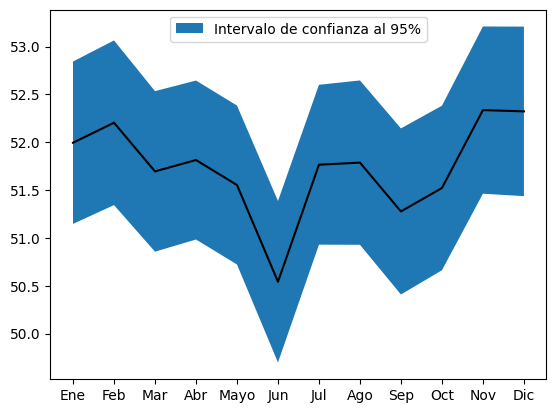

Tamaños muestrales según mes de la encuesta
mes_encuesta
Ene     27726
Feb     27071
Mar     28206
Abr     28834
Mayo    28697
Jun     27243
Jul     28477
Ago     26951
Sep     26133
Oct     26752
Nov     26309
Dic     25599
Name: activ, dtype: int64


In [15]:
def icp1(df: pd.DataFrame):
    alpha = 0.05
    cuantil = scipy.stats.norm.ppf(1-alpha/2)
    to = len(df[df["activ"] == 1]) / len(df)
    error = cuantil * np.sqrt(to / len(df))
    return [(to - error) * 100, (to + error) * 100]

fuerza_trabajo = data[(data["tramo_edad"].notnull()) & (data["activ"].notnull())]
meses = ["Ene", "Feb", "Mar", "Abr", 
         "Mayo", "Jun", "Jul", "Ago",
         "Sep", "Oct", "Nov", "Dic"]
data_mensual = fuerza_trabajo.groupby("mes_encuesta")

tamanos_muestrales = data_mensual["activ"].count()
tamanos_muestrales = tamanos_muestrales.rename(index={i: meses[i - 1] for i in range(1, 13)})

tasas_ocupacion = data_mensual.apply(lambda df: len(df[df["activ"] == 1]) / len(df) * 100)
ics_95 = data_mensual.apply(icp1)
ic_inf = []
ic_sup = []
for ic_95 in ics_95:
    ic_inf.append(ic_95[0])
    ic_sup.append(ic_95[1])
plt.plot(meses, tasas_ocupacion.values, color="black")


plt.fill_between(meses, ic_inf, ic_sup, label = "Intervalo de confianza al 95%")
plt.legend()
plt.show()

print("Tamaños muestrales según mes de la encuesta")
print(tamanos_muestrales)

## Análisis Temporal Ocupación

## Anexo
$$\sup L(p_1, p_2, p_3) \\ \text{sujeto a} \ \ \ p_1 + p_2 + p_3 = 1$$

donde L es la funcion de verosimilitud. Ahora, dado que la funcion logaritmo natural es estrictamente creciente, la expresion anterior es equivalente a calcular

$$\sup l(p_1, p_2, p_3) = \sup \ln (L(p_1, p_2, p_3)) \\ \text{sujeto a} \ \ \ p_1 + p_2 + p_3 = 1$$

Ahora, la funcion de verosimilitud esta dada por

\begin{align*}
    L(p_1, p_2, p_3) &= f(p_1, p_2, p_3 | \mathbf{Y}) \\
    & = \prod_{i = 1}^n f(y_i) \\
    & = \prod_{i = 1}^n p_1^{\frac{(y_i-2)(y_i-3)}{(1-2)(1-3)}} p_2^{\frac{(y_i-1)(y_i-3)}{(2-1)(2-3)}} p_3^{\frac{(y_i-1)(y_i-2)}{(3-1)(3-2)}} \\
    & = p_1^{\sum_{i = 1}^n \frac{(y_i - 2)(y_i -3)}{(1 - 2)(1 - 3)}} p_2^{\sum_{i = 1}^n \frac{(y_i - 1)(y_i -3)}{(2 - 1)(2 - 3)}} p_3^{\sum_{i = 1}^n \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)}}
\end{align*}

por lo que la funcion de log-verosimilitud se calcula como

\begin{align*}
    l(p_1, p_2, p_3) = \sum_{i = 1}^n \frac{(y_i - 2)(y_i -3)}{(1 - 2)(1 - 3)} \ln(p_1) + \sum_{i = 1}^n \frac{(y_i - 1)(y_i -3)}{(2 - 1)(2 - 3)} \ln(p_2) + \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)} \ln(p_3) 
\end{align*}

Luego, como queremos calcular el calcular el supremo dada la restriccion de las probabilidades, entonces calculamos el lagrangiano

$$L(p_1, p_2, p_3, \lambda) = l(p_1, p_2, p_3) - \lambda (p_1 + p_2 + p_3 - 1)$$

de modo que obtenemos las condiciones de Lagrange

$$\frac{\partial L}{\partial p_1} = \sum_{i = 1}^n \frac{(y_i - 2)(y_i -3)}{(1 - 2)(1 - 3)} \frac{1}{p_1} - \lambda = 0$$
$$\frac{\partial L}{\partial p_2} = \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 3)}{(2 - 1)(2 - 3)} \frac{1}{p_2} - \lambda = 0$$
$$\frac{\partial L}{\partial p_1} = \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)} \frac{1}{p_3} - \lambda = 0$$
$$\frac{\partial L}{\partial \lambda} = p_1 + p_2 + p_3 - 1 = 0$$

De estas ecuaciones, obtenemos que

$$p_1 = \frac{\sum_{i = 1}^n (y_i - 2)(y_i - 3)}{\lambda (1 - 2)(1 - 3)}$$
$$p_2 = \frac{\sum_{i = 1}^n (y_i - 1)(y_i - 3)}{\lambda (2 - 1)(2 - 3)}$$
$$p_3 = \frac{\sum_{i = 1}^n (y_i - 1)(y_i - 2)}{\lambda (3 - 1)(3 - 2)}$$

por lo que podemos reemplazar estos valores en la restriccion de igualdad

$$ \frac{1}{\lambda} \left(\sum_{i = 1}^n \frac{(y_i - 2)(y_i - 3)}{(1 - 2)(1 - 3)} + \frac{(y_i - 1)(y_i - 3)}{(2 - 1)(2 - 3)} + \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)}\right) = 1 $$

donde podemos notar que se cumple la siguiente igualdad

$$\frac{(y_i - 2)(y_i - 3)}{(1 - 2)(1 - 3)} + \frac{(y_i - 1)(y_i - 3)}{(2 - 1)(2 - 3)} + \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)} = 1$$

por lo que al reemplazar en la ecuacion anterior nos queda

$$\frac{1}{\lambda} \sum_{i = 1}^n 1 = \frac{n}{\lambda} = 1$$
$$\lambda = n$$

de modo que los EMV para cada probalidad son

$$\hat{p}_1 = \sum_{i = 1}^n \frac{(y_i - 2)(y_i - 3)}{n(1 - 2)(1 - 3)}$$
$$\hat{p}_2 = \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 3)}{n(2 - 1)(2 - 3)}$$
$$\hat{p}_3 = \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 2)}{n(3 - 1)(3 - 2)}$$

Ademas, por la construccion de la funcion densidad basada en los polinomios de Lagrange, para cada EMV se suma solo 1 por cada persona que contesta la opcion asignada a dicha probabilidad, por lo que los EMV se puede calcular como la proporcion de personas que contesta cada una de las 3 opciones posibles. Es decir, si se considera el grupo de las personas en edad de trabajar, el EMV de $p_1$ se calcula como

$$\hat{p}_1 = \frac{TO}{PET}$$

Luego, para realizar los intervalos de confianza y test de hipotesis, utilizamos la normalidad asintotica que caracteriza a los EMV, por lo que debemos calcular la matriz de informacion de Fisher

\begin{align*}
    \begin{bmatrix}
        \frac{n}{p_1} & 0 & 0 \\
        0 & \frac{n}{p_2} & 0 \\
        0 & 0 & \frac{n}{p_3}
    \end{bmatrix}
\end{align*}